# **`PUT`**

In [2]:
import pandas as pd

import scienceplots
import matplotlib.pyplot as plt
import numpy as np


plt.rcParams["text.usetex"] = False
plt.style.use(['science','no-latex'])

# def clean_plot_style():
#     plt.style.use("default")  # reset any weird styles
#     plt.rcParams.update({
#         "figure.figsize": (6, 4),
#         "axes.spines.top": False,
#         "axes.spines.right": False,
#         "axes.grid": True,
#         "grid.alpha": 0.3,
#         "font.size": 12,
#         "lines.linewidth": 2,
#         "axes.labelsize": 13,
#         "axes.titlesize": 14,
#         "xtick.labelsize": 11,
#         "ytick.labelsize": 11,
#         "text.usetex": False,   # critical for avoiding errors
#         "mathtext.fontset": "stix",
#     })

# clean_plot_style()


import matplotlib as mpl
mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif",
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
})

import matplotlib.pyplot as plt




# Tests on varied Hyperparameter ranges - **`PUT`**

## T

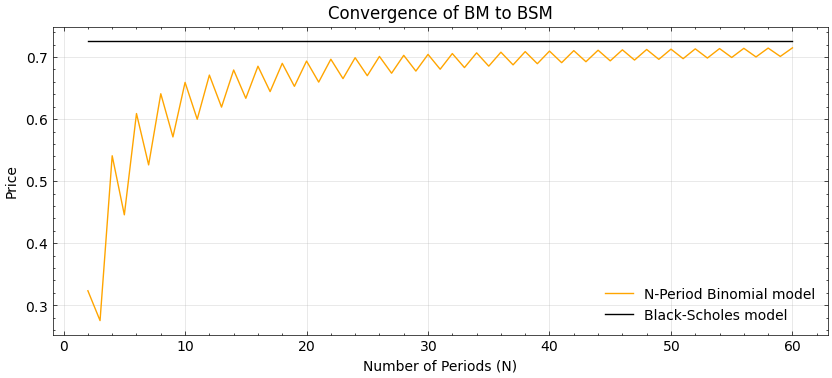

In [35]:
dft = pd.read_csv("-T.csv")
dft.head(), dft.columns

dft = pd.read_csv("-T.csv")
dft.head()
dft.columns
plot = dft[dft['hp'] == 50][['Binomial', 'BSM', 'Step']][1:60].plot(
    x = 'Step',
    figsize=(10, 4),
    title='Convergence of BM to BSM',
    xlabel = 'Number of Periods (N)',
    ylabel = 'Price',
    color=['orange','k'],


    # grid=True,
    # legend=True,
    # label=['N-Period Binomial model', 'Black-Scholes model'],
    # colorbar=True
    # colormap=
    # xerr = 0.4
    )
plot.legend(['N-Period Binomial model', 'Black-Scholes model'])   
plot.grid(True, alpha=0.4)

plt.show()

# BSM 99.9272	

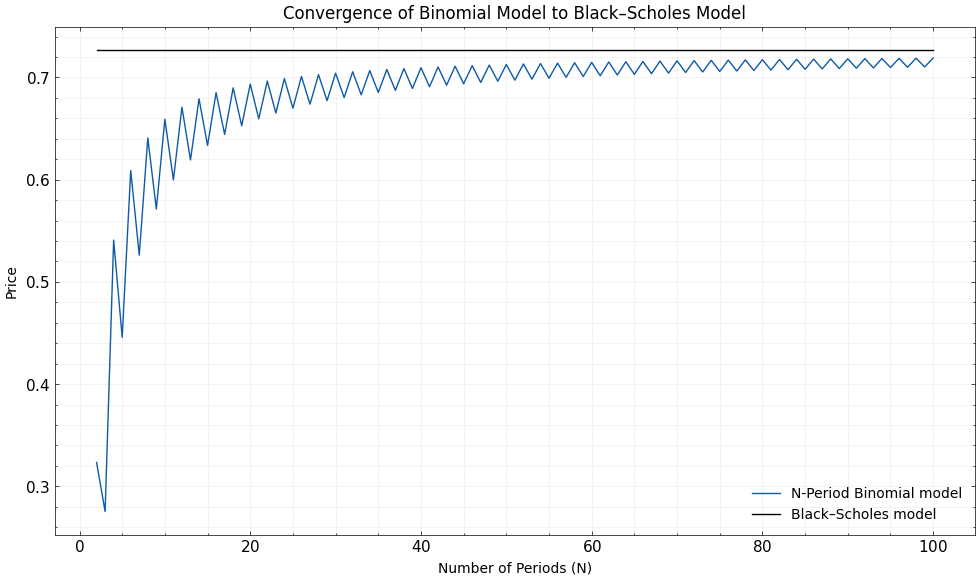

In [36]:
dft = pd.read_csv("-T.csv")

sub = dft[dft['hp'] == 50][['Binomial', 'BSM', 'Step']].iloc[1:100]

ax = sub.plot(
    x='Step',
    figsize=(10, 6),
    title='Convergence of Binomial Model to Black–Scholes Model',
    xlabel='Number of Periods (N)',
    ylabel='Price',
    color=["#0E5AA7", 'k'],
    fontsize=11
)

ax.legend([
    'N-Period Binomial model',
    'Black–Scholes model'
])

ax.grid(True, alpha=0.2, which='both')

ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)


plt.tight_layout()
plt.show()


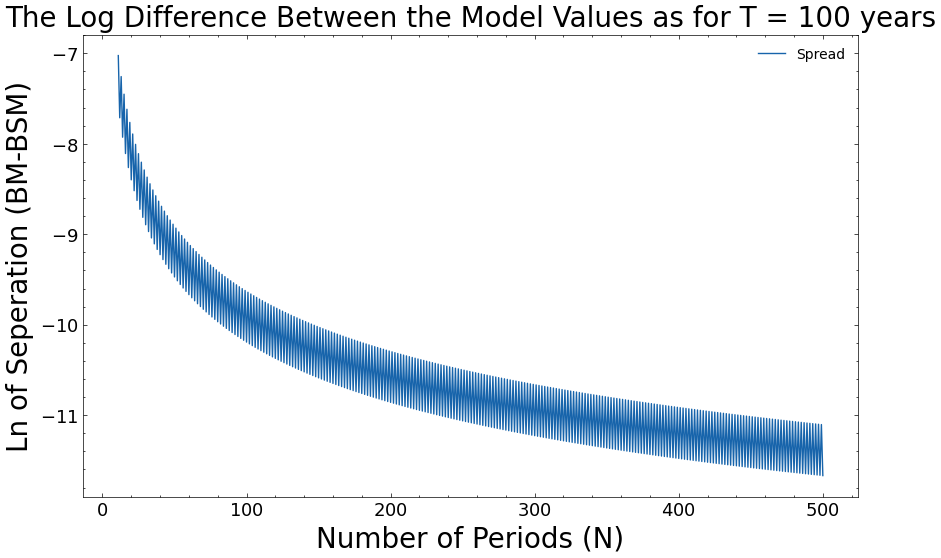

In [37]:
range_from = 10
range_until = 500
thishp = 100

plt.figure(figsize=(10,6))
cmap = plt.cm.Blues
color = cmap(0.8)

plt.plot(
    dft[dft['hp'] == thishp]["Step"][range_from:range_until],
    # [ x for x in dft[dft['hp'] == thishp]["Spread"][range_from:range_until]],
    [ np.log(x) for x in dft[dft['hp'] == thishp]["Spread"][range_from:range_until]],
    label="Spread",
    color=color
)

plt.xlabel("Number of Periods (N)")
plt.ylabel("Ln of Seperation (BM-BSM)")
plt.title(f"The Log Difference Between the Model Values as for T = {thishp} years")


# ---- CUSTOM FONT SIZES ----
plt.title(f"The Log Difference Between the Model Values as for T = {thishp} years", fontsize=20)     # Title font size
plt.xlabel("Number of Periods (N)", fontsize=20)              # X-label size
plt.ylabel("Ln of Seperation (BM-BSM)", fontsize=20)            # Y-label size

plt.xticks(fontsize=13)                      # X-tick font size
plt.yticks(fontsize=13)                      # Y-tick font size

# plt.legend(fontsize=20)                      # Legend font size
# ----------------------------------



plt.legend()

plt.show()



<Figure size 800x500 with 0 Axes>

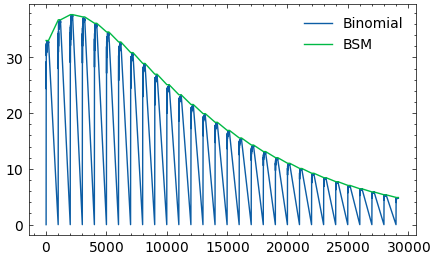

In [38]:
# dfsigsig[['Binomial', 'BSM']].plot(figsize=(50, 20))

plt.figure(figsize=(8,5))


dft[(dft['Step'] < 200) & (dft.index < 30_000)][['Binomial', 'BSM']].plot(figsize=(5, 3))


plt.show()




### Same

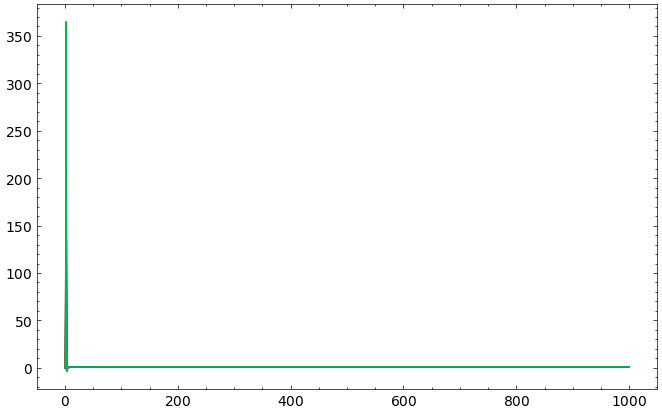

In [50]:
see_until_iterr = 1000
plt.figure(figsize=(8,5))

for ihp in range(17,201):
    dft[dft['hp'] == ihp]['Binomial']
    plt.plot(dft[dft['hp'] == ihp]['Step'][:see_until_iterr], dft[dft['hp'] == ihp]['Binomial'][:see_until_iterr] / dft[dft['hp'] == ihp]['BSM'][:see_until_iterr] )

plt.show()


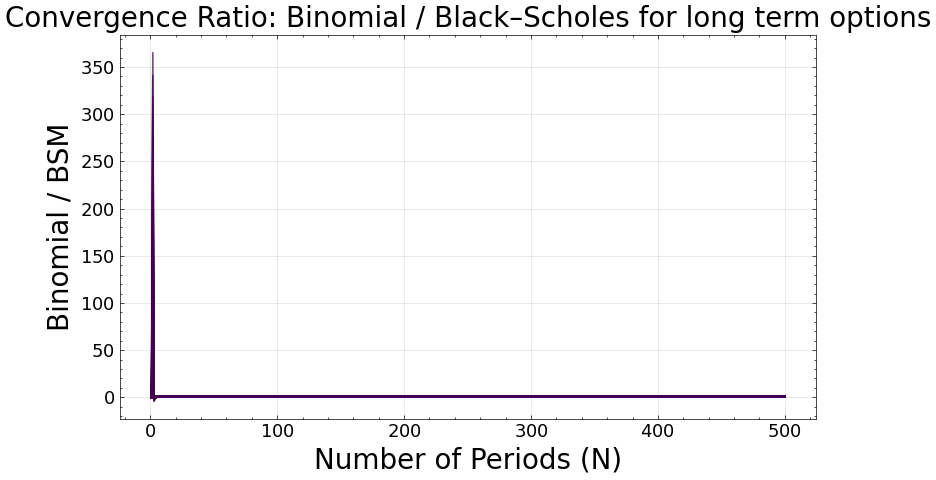

In [51]:
see_until_iterr = 500
plt.figure(figsize=(8,5))

for ihp in range(17, 201):

    # safe subset (avoids chained indexing)
    sub = dft[dft['hp'] == ihp].iloc[:see_until_iterr]

    cmap = plt.cm.viridis
    color = cmap(-2*(ihp - 17) / (201 - 17) + 0.35)

    plt.plot(
        sub['Step'],
        sub['Binomial'] / sub['BSM'],
        color=color,
        lw=1.2,
        alpha=0.7
    )

# ---- CUSTOM FONT SIZES ----
plt.title("Convergence Ratio: Binomial / Black–Scholes for long term options", fontsize=20)     # Title font size
plt.xlabel("Number of Periods (N)", fontsize=20)              # X-label size
plt.ylabel("Binomial / BSM", fontsize=20)            # Y-label size

plt.xticks(fontsize=13)                      # X-tick font size
plt.yticks(fontsize=13)                      # Y-tick font size

# plt.legend(fontsize=20)                      # Legend font size
# ----------------------------------


plt.grid(True, alpha=0.4)

# Optional: remove top/right for cleaner style
ax = plt.gca()
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

plt.tight_layout()
plt.show()


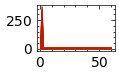

In [52]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(1,.6))

see_until_iterr = 60

# pick any colormap
cmap = plt.cm.turbo  # or 'viridis', 'plasma', 'magma', 'turbo', 'coolwarm' etc.

for idx, ihp in enumerate(range(17, 201)):
    color = cmap(idx / 200)
    df_sub = dft[dft['hp'] == ihp]
    plt.plot(
        df_sub['Step'][:see_until_iterr],
        df_sub['Binomial'][:see_until_iterr] / df_sub['BSM'][:see_until_iterr],
        color=color,
        linewidth=1
    )


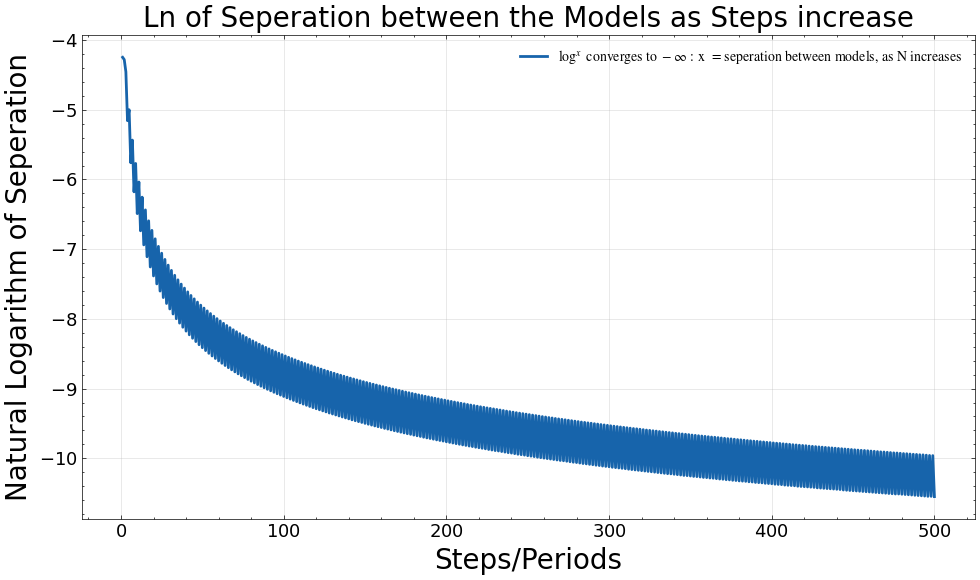

In [56]:
range_from = 0
range_until = 500

ihp = 90
plt.figure(figsize=(10,6))

cmap = plt.cm.Blues
color = cmap(0.8)

plt.plot(
    dft[dft['hp'] == ihp]['Step'].iloc[range_from:range_until],
    np.log(abs(dft[dft['hp'] == ihp]['Binomial'].iloc[range_from:range_until]-dft['BSM'][dft['hp'] == ihp].iloc[range_from:range_until])),
    label=r"$\log^x \text{ converges to } -\infty \text{ : x  = seperation between models, as N increases}$",
    color=color,
    linewidth=2,

    
)

# plt.title("Spread vs Step")
# plt.xlabel("Step")
# plt.ylabel("Spread")

# ---- CUSTOM FONT SIZES ----
plt.title("Ln of Seperation between the Models as Steps increase", fontsize=20)     # Title font size
plt.xlabel("Steps/Periods", fontsize=20)              # X-label size
plt.ylabel("Natural Logarithm of Seperation", fontsize=20)            # Y-label size

plt.xticks(fontsize=13)                      # X-tick font size
plt.yticks(fontsize=13)                      # Y-tick font size

plt.legend(fontsize=10)                      # Legend font size
# ----------------------------------


plt.grid(True, alpha=0.4)

ax = plt.gca()
ax.spines['top'].set_visible(1)
ax.spines['right'].set_visible(1)

plt.tight_layout()
plt.show()


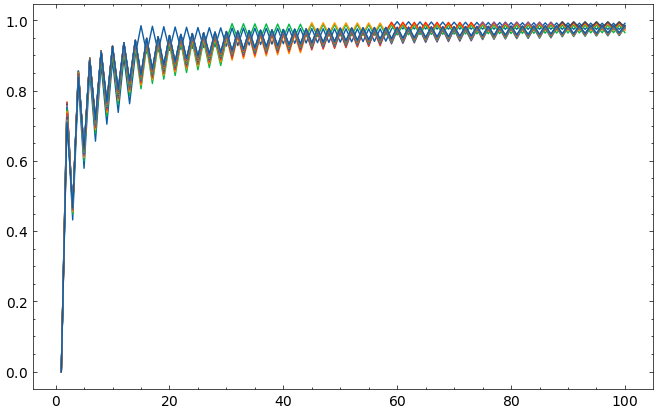

In [57]:
plt.figure(figsize=(8,5))


see_until_iterr = 100
for ihp in range(1,16):
    dft[dft['hp'] == ihp]['Binomial']
    plt.plot(dft[dft['hp'] == ihp]['Step'][:see_until_iterr], dft[dft['hp'] == ihp]['Binomial'][:see_until_iterr] / dft[dft['hp'] == ihp]['BSM'][:see_until_iterr] )

/var/folders/x7/qg3pwzcj4lq7gkhkzz_qd6c80000gn/T/ipykernel_52002/3830048897.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=20)                      # Legend font size


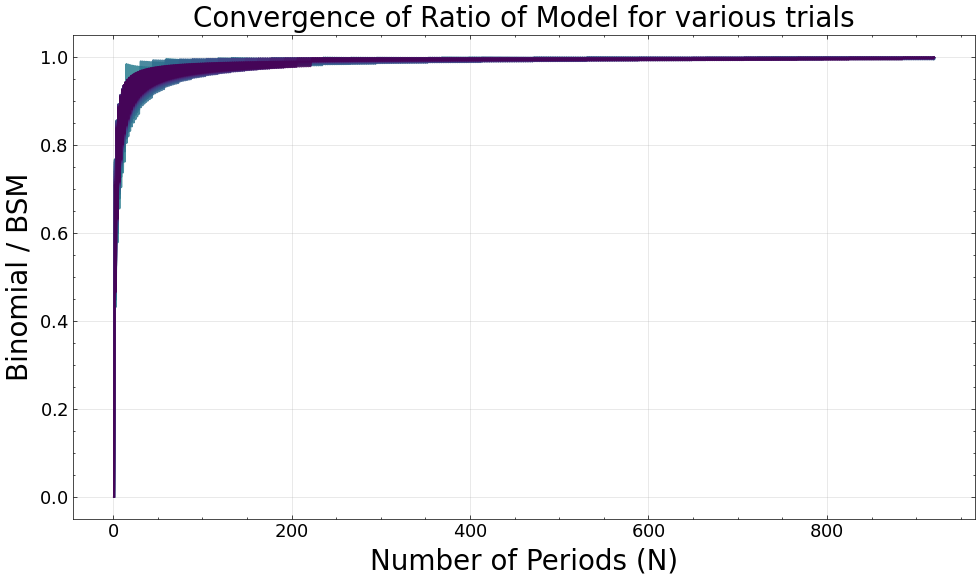

In [58]:
plt.figure(figsize=(10, 6))

see_until_iterr = 920


for ihp in range(1, 16):
    sub = dft[dft['hp'] == ihp].iloc[:see_until_iterr]   # safe slice

    cmap = plt.cm.viridis
    color = cmap(-0.5*(ihp ) / (17) + .45)

    plt.plot(
        sub['Step'],
        sub['Binomial'] / sub['BSM'],
        lw=1.5,
        alpha=0.85,
        color=color,
    )

# plt.title("Convergence of Ratio Binomial Model to Black–Scholes Model")
# plt.xlabel("Number of Periods (N)")
# plt.ylabel("Binomial / BSM")


# ---- CUSTOM FONT SIZES ----
plt.title("Convergence of Ratio of Model for various trials", fontsize=20)     # Title font size
plt.xlabel("Number of Periods (N)", fontsize=20)              # X-label size
plt.ylabel("Binomial / BSM", fontsize=20)            # Y-label size

plt.xticks(fontsize=13)                      # X-tick font size
plt.yticks(fontsize=13)                      # Y-tick font size

plt.legend(fontsize=20)                      # Legend font size
# ----------------------------------

plt.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


## S

In [45]:
dfs = pd.read_csv("-S.csv")
dfs.head(), dfs.columns

(   Step  hp      BSM  Binomial    Spread
 0     1   1  71.7933   71.7837  0.009602
 1     2   1  71.7933   71.7837  0.009602
 2     3   1  71.7933   71.7837  0.009602
 3     4   1  71.7933   71.7837  0.009602
 4     5   1  71.7933   71.2364  0.556915,
 Index(['Step', 'hp', 'BSM', 'Binomial', 'Spread'], dtype='object'))

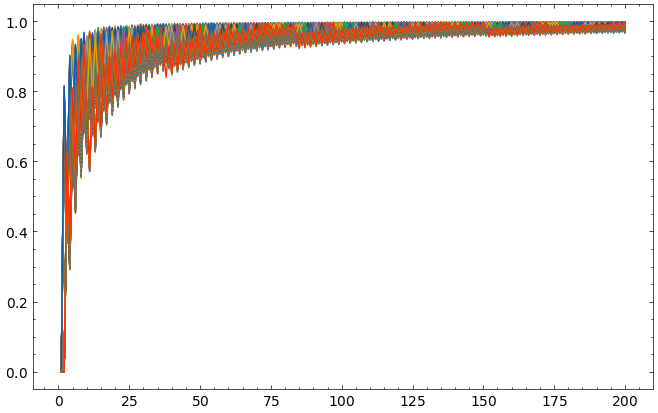

In [46]:
see_until_iterr = 200
plt.figure(figsize=(8,5))

for ihp in range(50,201):
    dfs[dfs['hp'] == ihp]['Binomial']
    plt.plot(dfs[dfs['hp'] == ihp]['Step'][:see_until_iterr], dfs[dfs['hp'] == ihp]['Binomial'][:see_until_iterr] / dfs[dfs['hp'] == ihp]['BSM'][:see_until_iterr] )

/var/folders/x7/qg3pwzcj4lq7gkhkzz_qd6c80000gn/T/ipykernel_52002/747738203.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=20)                      # Legend font size


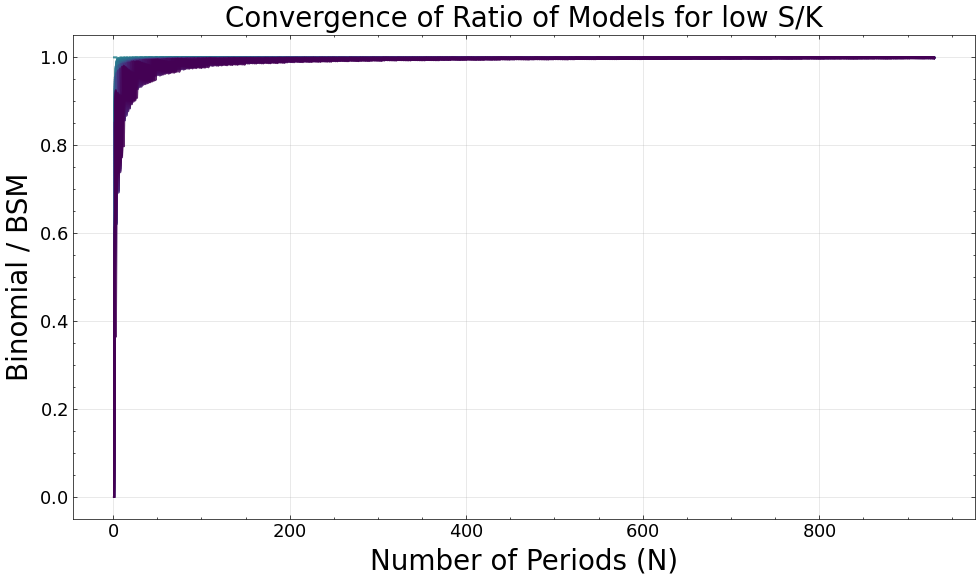

In [47]:
# see_until_iterr = 500
# plt.figure(figsize=(8,5))

# for ihp in range(1,50):
#     dfs[dfs['hp'] == ihp]['Binomial']
#     plt.plot(dfs[dfs['hp'] == ihp]['Step'][:see_until_iterr], dfs[dfs['hp'] == ihp]['Binomial'][:see_until_iterr] / dfs[dfs['hp'] == ihp]['BSM'][:see_until_iterr] )



see_until_iterr = 500+430
plt.figure(figsize=(10, 6))

cmap = plt.cm.viridis   # same colormap as original

for ihp in range(1, 50):
    sub = dfs[dfs['hp'] == ihp].iloc[:see_until_iterr]   # safe slice

    # same colour mapping as your original code
    color = cmap(-0.5 * (ihp) / (50 + 2) + 0.45)

    plt.plot(
        sub['Step'],
        sub['Binomial'] / sub['BSM'],
        lw=1.5,
        alpha=0.85,
        color=color,
    )

# ---- CUSTOM FONT SIZES ----
plt.title("Convergence of Ratio of Models for low S/K", fontsize=20)     # Title font size
plt.xlabel("Number of Periods (N)", fontsize=20)              # X-label size
plt.ylabel("Binomial / BSM", fontsize=20)            # Y-label size

plt.xticks(fontsize=13)                      # X-tick font size
plt.yticks(fontsize=13)                      # Y-tick font size

plt.legend(fontsize=20)                      # Legend font size
# ----------------------------------


plt.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


## K ~~~

In [60]:
dfk = pd.read_csv("-K.csv")
dfk.head(), dfk.columns

(   Step  hp       BSM  Binomial    Spread
 0     1   1  0.001371       0.0  0.001371
 1     2   1  0.001371       0.0  0.001371
 2     3   1  0.001371       0.0  0.001371
 3     4   1  0.001371       0.0  0.001371
 4     5   1  0.001371       0.0  0.001371,
 Index(['Step', 'hp', 'BSM', 'Binomial', 'Spread'], dtype='object'))

/var/folders/x7/qg3pwzcj4lq7gkhkzz_qd6c80000gn/T/ipykernel_52002/4288407422.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=20)                      # Legend font size


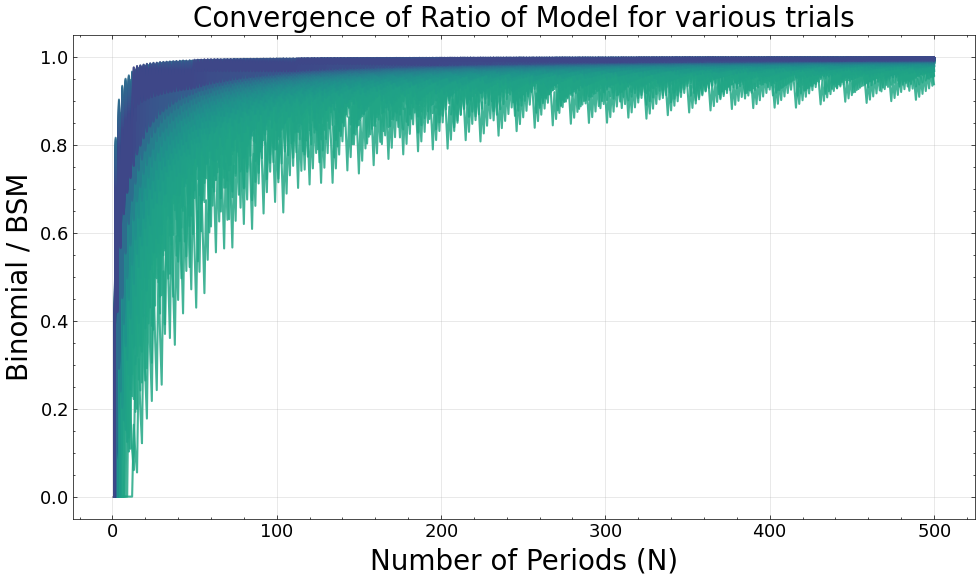

In [63]:


# for ihp in range(1,201):
#     dfk[dfk['hp'] == ihp]['Binomial']
#     plt.plot(dfk[dfk['hp'] == ihp]['Step'][:see_until_iterr], dfk[dfk['hp'] == ihp]['Binomial'][:see_until_iterr] / dfk[dfk['hp'] == ihp]['BSM'][:see_until_iterr] )




see_until_iterr = 500
plt.figure(figsize=(10, 6))

cmap = plt.cm.viridis   # same colormap as original

for ihp in range(1, 201):
    sub = dfk[dfk['hp'] == ihp].iloc[:see_until_iterr]   # safe slice

    # same colour mapping as your original code
    color = cmap(-0.5 * (ihp) / (200 + 2) + 0.60)

    plt.plot(
        sub['Step'],
        sub['Binomial'] / sub['BSM'],
        lw=1.5,
        alpha=0.85,
        color=color,
    )


# ---- CUSTOM FONT SIZES ----
plt.title("Convergence of Ratio of Model for various trials", fontsize=20)     # Title font size
plt.xlabel("Number of Periods (N)", fontsize=20)              # X-label size
plt.ylabel("Binomial / BSM", fontsize=20)            # Y-label size

plt.xticks(fontsize=13)                      # X-tick font size
plt.yticks(fontsize=13)                      # Y-tick font size

plt.legend(fontsize=20)                      # Legend font size
# ----------------------------------



# plt.legend(["The colour gradient is added to depict the \ndifferent paths we observe for our trials"])
plt.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

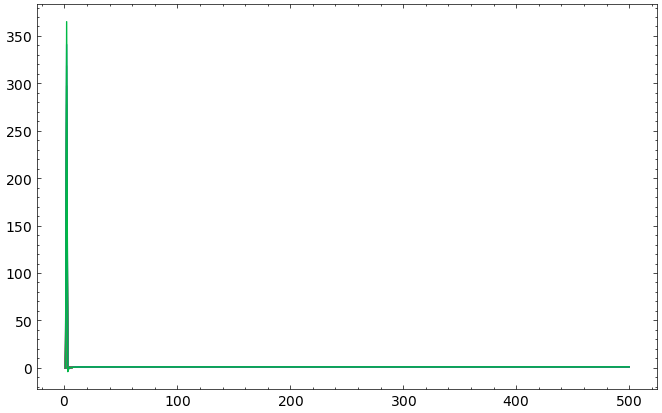

In [65]:
see_until_iterr = 500
plt.figure(figsize=(8,5))

for ihp in range(17,201):
    dft[dft['hp'] == ihp]['Binomial']
    plt.plot(dft[dft['hp'] == ihp]['Step'][:see_until_iterr], dft[dft['hp'] == ihp]['Binomial'][:see_until_iterr] / dft[dft['hp'] == ihp]['BSM'][:see_until_iterr] )

plt.show()


## r

In [66]:
dfr = pd.read_csv("-r.csv")
dfr.head(), dfr.columns

(   Step  hp    BSM  Binomial    Spread
 0     1   1  70.94    0.0000  70.94000
 1     2   1  70.94   60.0250  10.91500
 2     3   1  70.94   39.6889  31.25110
 3     4   1  70.94   64.2202   6.71981
 4     5   1  70.94   49.8384  21.10150,
 Index(['Step', 'hp', 'BSM', 'Binomial', 'Spread'], dtype='object'))

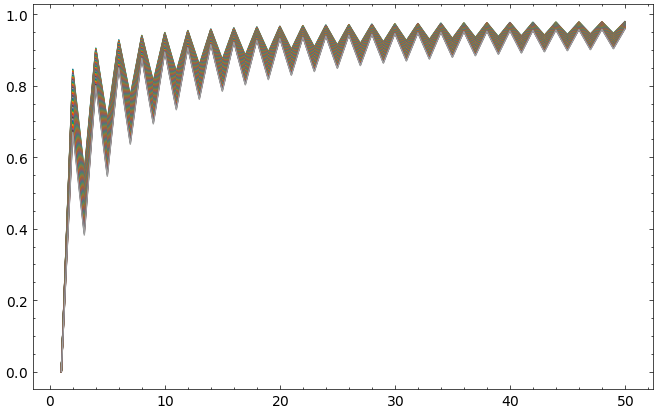

In [67]:
see_until_iterr = 50
plt.figure(figsize=(8,5))

for ihp in range(1,50):
    dfr[dfr['hp'] == ihp]['Binomial']
    plt.plot(dfr[dfr['hp'] == ihp]['Step'][:see_until_iterr], dfr[dfr['hp'] == ihp]['Binomial'][:see_until_iterr] / dfr[dfr['hp'] == ihp]['BSM'][:see_until_iterr] )

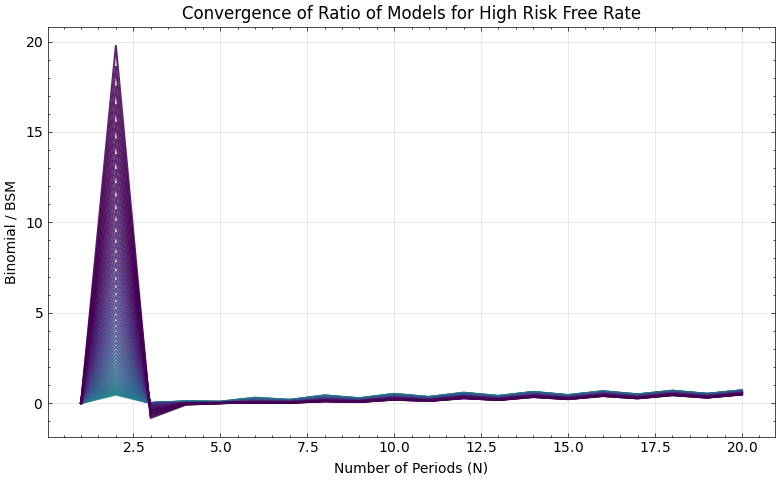

In [68]:
# see_until_iterr = 500
# plt.figure(figsize=(8,5))

# for ihp in range(150,200):
#     dfr[dfr['hp'] == ihp]['Binomial']
#     plt.plot(dfr[dfr['hp'] == ihp]['Step'][:see_until_iterr], dfr[dfr['hp'] == ihp]['Binomial'][:see_until_iterr] / dfr[dfr['hp'] == ihp]['BSM'][:see_until_iterr] )




see_until_iterr = 20
plt.figure(figsize=(8, 5))

cmap = plt.cm.viridis   # same colormap as original

for ihp in range(150, 200):
    sub = dfr[dfr['hp'] == ihp].iloc[:see_until_iterr]   # safe slice

    # same colour mapping as your original code
    color = cmap(-0.5 * (ihp-150) / (50) + 0.45)

    plt.plot(
        sub['Step'],
        sub['Binomial'] / sub['BSM'],
        lw=1.5,
        alpha=0.85,
        color=color,
    )

plt.title("Convergence of Ratio of Models for High Risk Free Rate")
plt.xlabel("Number of Periods (N)")
plt.ylabel("Binomial / BSM")
plt.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

## sig

In [3]:
dfsig = pd.read_csv("-sig.csv")
dfsig.head(), dfsig.columns

(   Step  hp      BSM  Binomial    Spread
 0     1   1  1.41414  0.000000  1.414140
 1     2   1  1.41414  1.028300  0.385846
 2     3   1  1.41414  0.063616  1.350530
 3     4   1  1.41414  0.012608  1.401530
 4     5   1  1.41414  0.181024  1.233120,
 Index(['Step', 'hp', 'BSM', 'Binomial', 'Spread'], dtype='object'))

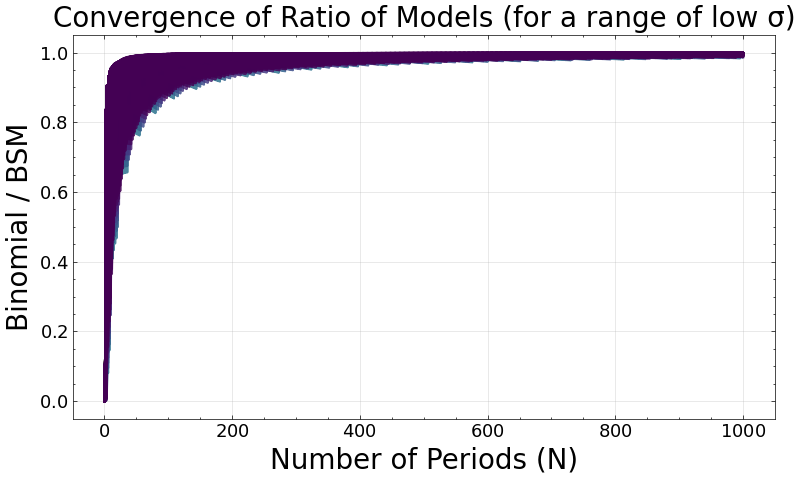

In [5]:
# see_until_iterr = 100
# plt.figure(figsize=(8,5))

# for ihp in range(1,45):
#     dfsig[dfsig['hp'] == ihp]['Binomial']
#     plt.plot(dfsig[dfsig['hp'] == ihp]['Step'][:see_until_iterr], dfsig[dfsig['hp'] == ihp]['Binomial'][:see_until_iterr] / dfsig[dfsig['hp'] == ihp]['BSM'][:see_until_iterr] )

see_until_iterr = 1000
plt.figure(figsize=(8, 5))

cmap = plt.cm.viridis   # same colormap

for ihp in range(1, 405):
    sub = dfsig[dfsig['hp'] == ihp].iloc[:see_until_iterr]   # safe slice

    # same color style as old code but scaled to range 1..45
    color = cmap(-0.5 * ihp / (5 + 2) + 0.45)

    plt.plot(
        sub['Step'],
        sub['Binomial'] / sub['BSM'],
        lw=1.5,
        alpha=0.85,
        color=color,
    )


# ---- CUSTOM FONT SIZES ----
plt.title("Convergence of Ratio of Models (for a range of low σ)", fontsize=20)     # Title font size
plt.xlabel("Number of Periods (N)", fontsize=20)              # X-label size
plt.ylabel("Binomial / BSM", fontsize=20)            # Y-label size

plt.xticks(fontsize=13)                      # X-tick font size
plt.yticks(fontsize=13)                      # Y-tick font size

# plt.legend(fontsize=20)                      # Legend font size
# ----------------------------------



plt.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


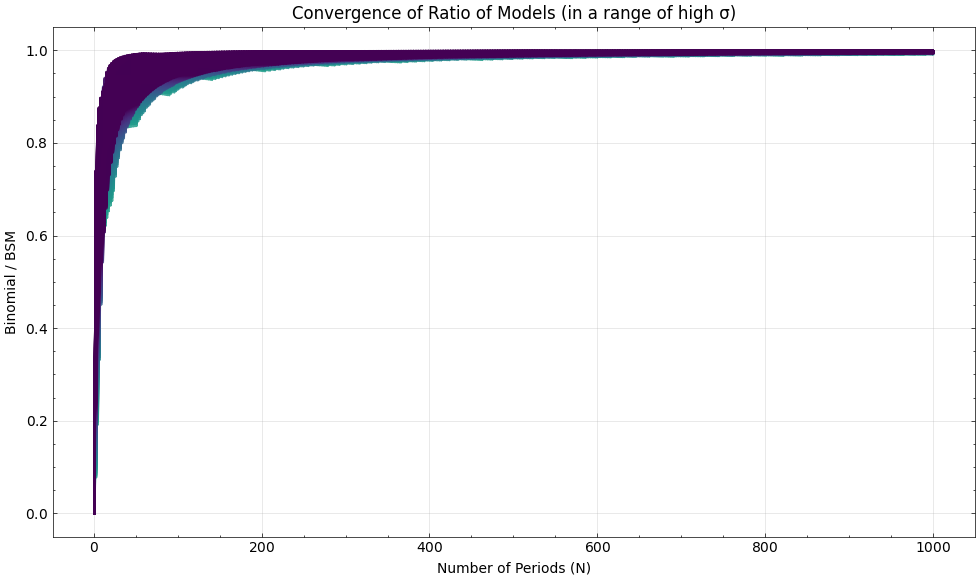

In [6]:

see_until_iterr = 3000
# plt.figure(figsize=(8,5))

# for ihp in range(50,201):
#     dfsig[dfsig['hp'] == ihp]['Binomial']
#     plt.plot(dfsig[dfsig['hp'] == ihp]['Step'][:see_until_iterr], dfsig[dfsig['hp'] == ihp]['Binomial'][:see_until_iterr] / dfsig[dfsig['hp'] == ihp]['BSM'][:see_until_iterr] )



plt.figure(figsize=(10, 6))

cmap = plt.cm.viridis   # same colormap

for ihp in range(30, 201):
    sub = dfsig[dfsig['hp'] == ihp].iloc[:see_until_iterr]   # safe slice

    # same color style as old code but scaled to range 1..45
    color = cmap(-1.9 * (ihp-50) / (150) + 0.300)

    plt.plot(
        sub['Step'],
        sub['Binomial'] / sub['BSM'],
        lw=1.5,
        alpha=0.85,
        color=color,
    )

plt.title("Convergence of Ratio of Models (in a range of high σ)")
plt.xlabel("Number of Periods (N)")
plt.ylabel("Binomial / BSM")
plt.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()